In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

import sys
sys.path.append('..')

import PyESRSTM

# Time Propagation 

In some cases, long time solution alone is not sufficient, and we need to look at initial conditions. In that case we can propagate the quantum in time by integrationg the QME. This is much more computationally demanding but can give us further insight.

We start by defining a system, with $(1+A\cos\omega t)^2$ time dependence of the rates, and looking at the long time solution.  

Hermiticity check passed!


/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/micromamba/envs/pyscf-env/lib/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


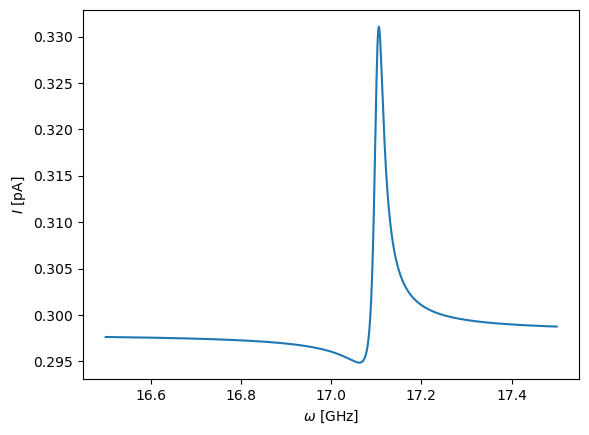

In [2]:
A = .5 
freq = 17.1

dot = PyESRSTM.QD(-30, 100, np.array([0.5]), np.array([[0.20804273,  0.00000000,  0.57159271]]), np.array([[2.0, 2.0, 2.0]]))
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000, Adrive=.5)

freq_long_time = np.linspace(16.5, 17.5, 1000)
I_long_time = PyESRSTM.ESR.ESR(Left, Right, dot, freq_long_time, NFL=1)
# the returned signal is in the shape (len(freq), 2*NFL+1)

plt.plot(freq_long_time, I_long_time[:, 2])
plt.xlabel(r'$\omega$ [GHz]')
plt.ylabel(r'$I$ [pA]')
plt.show()


Next we can calculate the evolution of the system near the resonance frequency, we chose $\omega = 17$ GHz.

`propagete_density` function takes in the rates [Hart], the energy differecnes `dot.Delta` [Hart], frequency [Ghz], and the total time [ns]. The units are a little bit of a mismatch since some of the input values come from other parts of the code, and thus are in atomic units and frequency and time are user defined. 
We also define the initial state of the impurity, in this case it is fully in the ground state. 

In [3]:
GRplus, GRminus = PyESRSTM.rates(dot, Right, 0,  0)
GLplus, GLminus = PyESRSTM.rates(dot, Left, 20,  1)

GL = GLplus + GLminus
GR = GRplus + GRminus
GC = GLplus - GLminus

In [4]:
rho0 = np.zeros((4,4), dtype=complex)
rho0[0, 0] = 1

kwargs = {'max_step': 0.005, 'method': 'RK45'}
time, rhot = PyESRSTM.propagate_density(GL, GR, dot.Delta, rho0, 700, frequency=17.1, kwargs=kwargs)

Integration successful: True, message: The solver successfully reached the end of the integration interval.


Bellow we plot the results. 
We also calculate the current using `current_in_time` which, takes the array of times, evolution of rho, and GC 
Finally we fit the amplitude, frequency and decay, and quality factor of the Rabi oscillations.

Rabi oscillation: 
  A = 0.496
  Omega = 75.811 [MHz]
  T2 = 36.799 [ns]
  QF = 0.444


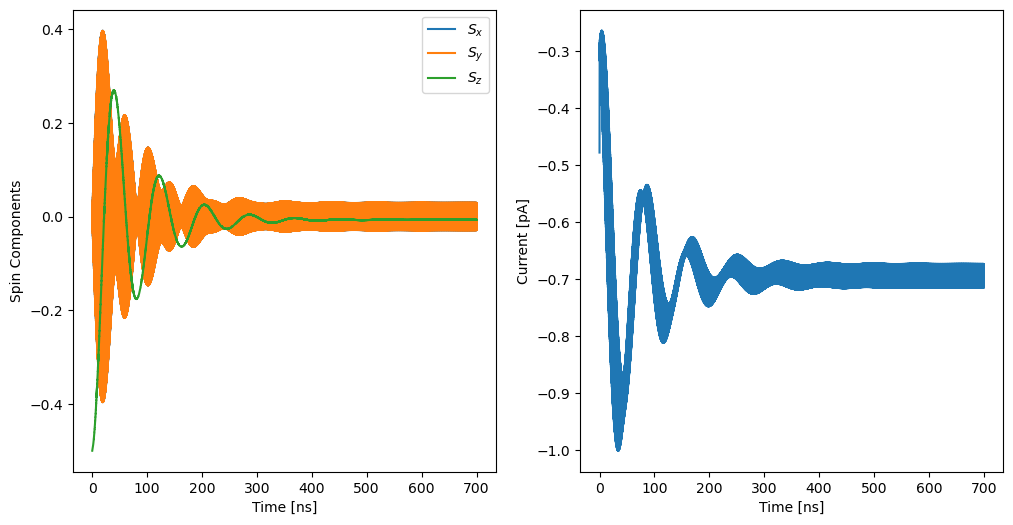

In [5]:
fig, ax = plt.subplots(1,2 , figsize=(12,6))
ax = ax.flatten()


Sx = 1/2*np.real(rhot[:, 0, 1] + rhot[:, 1, 0])
Sy = 1/2*np.real(1j*(rhot[:, 0,1] - rhot[:, 1,0]))
Sz = 1/2*np.real(rhot[:,1, 1] - rhot[:,0, 0])

I = PyESRSTM.current_in_time(time, rhot, GC, 17.1)


def rabi_oscillation(x, A, omega, T2):
    return A * np.exp(-x/(2*T2)) * np.cos(omega*x)

popt, pcov = curve_fit(rabi_oscillation, time, Sz)

print(f"Rabi oscillation: \n  A = {np.round(np.abs(popt[0]),3)}\n  Omega = {np.round(1000*np.abs(popt[1]),3)} [MHz]\n  T2 = {np.round(popt[2],3)} [ns]\n  QF = {np.round(popt[2]*np.abs(popt[1])/(2*np.pi),3)}")

ax[0].plot(time, Sx, label=r'$S_x$')
ax[0].plot(time, Sy, label=r'$S_y$')
ax[0].plot(time, Sz, label=r'$S_z$')
ax[1].plot(time, I,)

ax[0].set_xlabel('Time [ns]')
ax[0].set_ylabel('Spin Components')
ax[0].legend()
ax[1].set_xlabel('Time [ns]')
ax[1].set_ylabel('Current [pA]')

plt.show()


Likewise we can look at what happens if we initiate the system in a charged, state, and look at the population lifetime $T_1$

Integration successful: True, message: The solver successfully reached the end of the integration interval.
T1 = 0.10735274875207075 [ns]


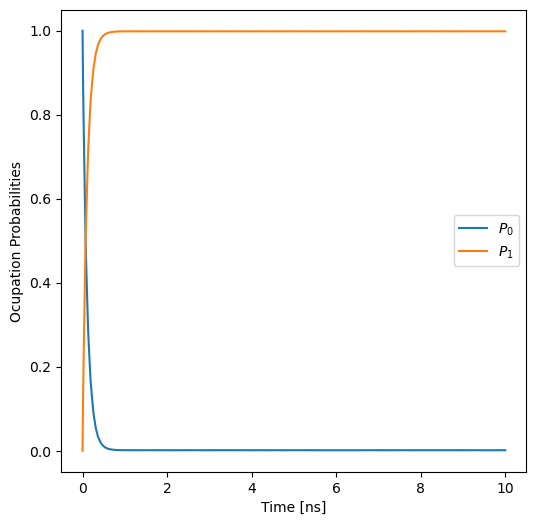

In [6]:
rho0 = np.zeros((4,4), dtype=complex)
rho0[2, 2] = 1

kwargs = {'max_step': 0.005, }
time, rhot = PyESRSTM.propagate_density(GL, GR, dot.Delta, rho0, 10, frequency=17.1, kwargs=kwargs)

def fit_decay(x, T1):
    return np.exp(-x/T1)

popt, pcov = curve_fit(fit_decay, time, np.real(rhot[:, 2,2]))

print(f"T1 = {popt[0]} [ns]") 

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(time, np.real(rhot[:, 2,2]), label=r'$P_{0}$')
ax.plot(time, np.real(rhot[:, 0,0]+rhot[:, 1,1]), label=r'$P_{1}$')


ax.set_xlabel('Time [ns]')
ax.set_ylabel('Ocupation Probabilities')
ax.legend()
plt.show()

### Inputing Time-depependece

To allow for more flexibility in driving functions, there are two additional ways to describe the driving of the system. 
First one we have already used, we pass all Fourier components of GL and GR tensors with shape (Ndim, Ndim, Ndim, Ndim, NF).

However, we can also describe a driving with more than a single frequency. 
In this case we pass GL and GR as tensor of shape (Ndim, Ndim, Ndim, Ndim, 1), and separately a list of frequencies and their associated amplitudes. 
The resulting rates will be written as $\Gamma (t) = \Gamma (0)\sum_n A_n \cos \omega_n t$. 

Alternatively the user can predefine the driving function in that case the function needs the $t$, $\rho(t)$ $M_L$ and $M_R$ (shape (Ndim,Ndim,Ndim,Ndim)), and return $\Delta \rho (t)$.

The three examples below, show a simple cosine driving from above implemented in three different ways. 
To be more transparent we recreated the hopping rates.

In [7]:
Right = PyESRSTM.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyESRSTM.Electrode(-25, 0, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000, Adrive=0)

GRplus, GRminus = PyESRSTM.rates(dot, Right, 0,  0)
GLplus, GLminus = PyESRSTM.rates(dot, Left, 20,  1)


GL = GLplus + GLminus
GR = GRplus + GRminus

GL[:,:,:,:,0] = GL[:,:,:,:,1] * A
GL[:,:,:,:,2] = GL[:,:,:,:,1] * A

kwargs = {'max_step': 0.005, 'method': 'RK45'}
rho0 = np.zeros((4,4), dtype=complex)
rho0[0, 0] = 1


In [8]:
time_four, rhot_four = PyESRSTM.propagate_density(GL, GR, dot.Delta, rho0, 70, frequency=freq, kwargs=kwargs)

# for adrinving the frequncy most be an array now, and we only care about the the 0th fourier component of GL 
time_A, rhot_A = PyESRSTM.propagate_density(GL[:,:,:,:,1:2], GR, dot.Delta, rho0, 70, frequency=np.array([freq]), adrive=np.array([2*A]), kwargs=kwargs)

# The predifined driving function is below
# !!! Mind the unit conversion of frequency, time input will be in atomic units. 
def single_step_adrive_add_hoc(t, rho, ML, MR):
    phase = 1 + 2*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    M_t = MR + ML * phase
    drho = np.einsum('ljvu,vu->lj', M_t, rho)
    return drho



time_hand, rhot_hand = PyESRSTM.propagate_density(GL[:,:,:,:,1:2], GR, dot.Delta, rho0, 70,  drho_function=single_step_adrive_add_hoc, kwargs=kwargs)

Integration successful: True, message: The solver successfully reached the end of the integration interval.
Integration successful: True, message: The solver successfully reached the end of the integration interval.
Integration successful: True, message: The solver successfully reached the end of the integration interval.


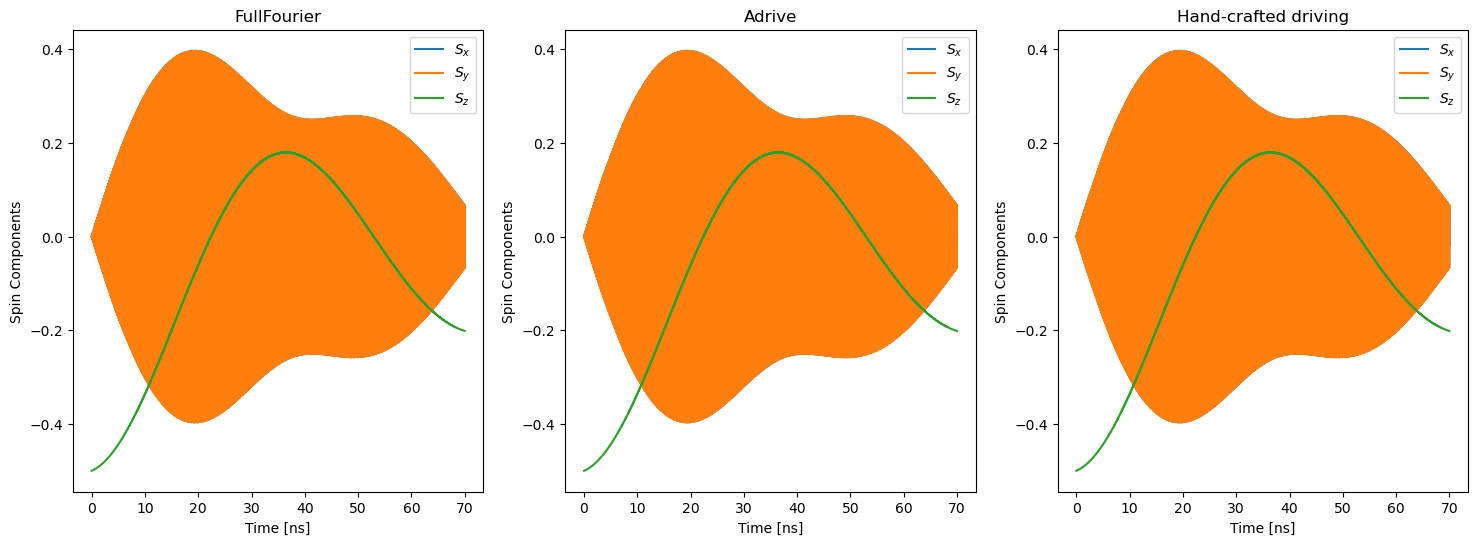

In [13]:
fig, ax = plt.subplots(1,3 , figsize=(18,6))
ax = ax.flatten()

Sx_four = 1/2*np.real(rhot_four[:, 0, 1] + rhot_four[:, 1, 0])
Sy_four = 1/2*np.real(1j*(rhot_four[:, 0,1] - rhot_four[:, 1,0]))
Sz_four = 1/2*np.real(rhot_four[:,1, 1] - rhot_four[:,0, 0])

ax[0].plot(time_four, Sx_four, label=r'$S_x$')
ax[0].plot(time_four, Sy_four, label=r'$S_y$')
ax[0].plot(time_four, Sz_four, label=r'$S_z$')
ax[0].set_title('FullFourier')

Sx_A = 1/2*np.real(rhot_A[:, 0, 1] + rhot_A[:, 1, 0])
Sy_A = 1/2*np.real(1j*(rhot_A[:, 0,1] - rhot_A[:, 1,0]))
Sz_A = 1/2*np.real(rhot_A[:,1, 1] - rhot_A[:,0, 0])

ax[1].plot(time_A, Sx_A, label=r'$S_x$')
ax[1].plot(time_A, Sy_A, label=r'$S_y$')
ax[1].plot(time_A, Sz_A, label=r'$S_z$')
ax[1].set_title('Adrive')


Sx_hand = 1/2*np.real(rhot_hand[:, 0, 1] + rhot_hand[:, 1, 0])
Sy_hand = 1/2*np.real(1j*(rhot_hand[:, 0,1] - rhot_hand[:, 1,0]))
Sz_hand = 1/2*np.real(rhot_hand[:,1, 1] - rhot_hand[:,0, 0])

ax[2].plot(time_hand, Sx_hand, label=r'$S_x$')
ax[2].plot(time_hand, Sy_hand, label=r'$S_y$')
ax[2].plot(time_hand, Sz_hand, label=r'$S_z$')
ax[2].set_title('Hand-crafted driving')

for a in ax:
    a.set_xlabel('Time [ns]')
    a.set_ylabel('Spin Components')
    a.legend() 

plt.show()

Likewise we have three ways to specify readout 

In [ ]:
I_four = PyESRSTM.current_in_time(time_four, rhot_four, GC, frequency=freq)
I_A = PyESRSTM.current_in_time(time_A, rhot_A, GC, frequency=np.array([freq]), adrive=np.array([2*A]))

def GC_adrive_add_hoc(GC, t):
    phase = 1 + 2*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    return GC[:,:,:,:,0] * phase

I_hand = PyESRSTM.current_in_time(time_hand, rhot_hand, GC, Gt_function=single_step_adrive_add_hoc)

### Multiple frequencies
Using the Adriving method we can look at what happens when we drive, with two otherwise unrealated frequencies. Spoiler, for a spin 1/2 impurity this doesn't do anything.

In [10]:
time_single, rhot_single = PyESRSTM.propagate_density(GL[:,:,:,:,1:2], GR, dot.Delta, rho0, 300, frequency=np.array([freq]), adrive=np.array([2*A]), kwargs=kwargs)
time_double, rhot_double = PyESRSTM.propagate_density(GL[:,:,:,:,1:2], GR, dot.Delta, rho0, 300, frequency=np.array([freq, freq+.5]), adrive=np.array([2*A,A]), kwargs=kwargs)

Integration successful: True, message: The solver successfully reached the end of the integration interval.
Integration successful: True, message: The solver successfully reached the end of the integration interval.


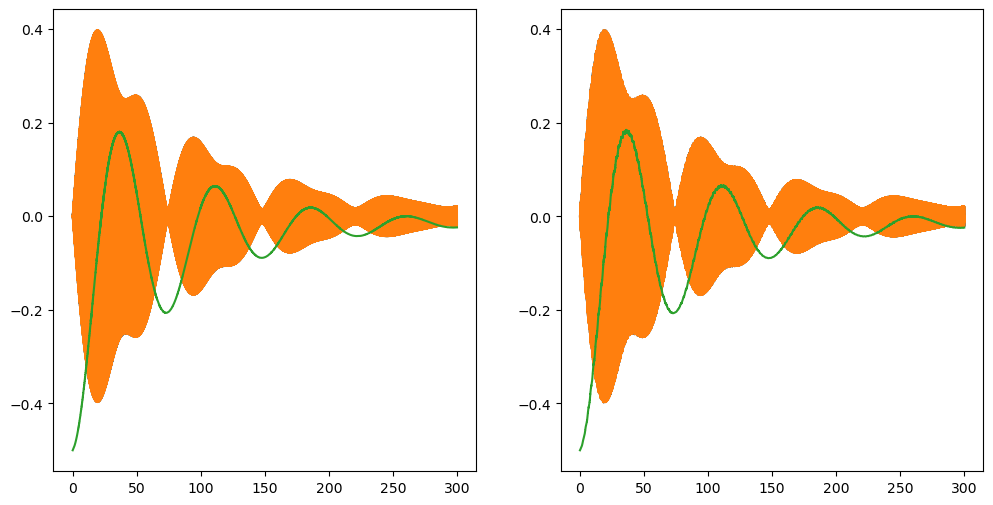

In [12]:
fig, ax = plt.subplots(1,2 , figsize=(12,6))

Sx_single = 1/2*np.real(rhot_single[:, 0, 1] + rhot_single[:, 1, 0])
Sy_single = 1/2*np.real(1j*(rhot_single[:, 0,1] - rhot_single[:, 1,0]))
Sz_single = 1/2*np.real(rhot_single[:,1, 1] - rhot_single[:,0, 0])

ax[0].plot(time_single, Sx_single, label=r'$S_x$')
ax[0].plot(time_single, Sy_single, label=r'$S_y$')
ax[0].plot(time_single, Sz_single, label=r'$S_z$')

Sx_double = 1/2*np.real(rhot_double[:, 0, 1] + rhot_double[:, 1, 0])
Sy_double = 1/2*np.real(1j*(rhot_double[:, 0,1] - rhot_double[:, 1,0]))
Sz_double = 1/2*np.real(rhot_double[:,1, 1] - rhot_double[:,0, 0])

ax[1].plot(time_double, Sx_double, label=r'$S_x$')
ax[1].plot(time_double, Sy_double, label=r'$S_y$')
ax[1].plot(time_double, Sz_double, label=r'$S_z$')

plt.show()


### Pulsing
Using the add hoc driving we can create pulses. Bellow we increase the driving strength every 50 ns, until 200 ns after which the driving is turned off. 

In [14]:
def single_step_adrive_add_hoc(t, rho, ML, MR):
    phase = 1 
    if t < 50/PyESRSTM.time_unit:
        phase += A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    elif t < 100/PyESRSTM.time_unit:
        phase += 2*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    elif t < 150/PyESRSTM.time_unit:
        phase += 4*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)
    elif t < 200/PyESRSTM.time_unit:
        phase += 6*A*np.cos(freq * t * 2 * np.pi*PyESRSTM.time_unit)  
        
    M_t = MR + ML * phase
    drho = np.einsum('ljvu,vu->lj', M_t, rho)
    return drho

time_pulse, rhot_pulse = PyESRSTM.propagate_density(GL[:,:,:,:,1:2], GR, dot.Delta, rho0, 300,  drho_function=single_step_adrive_add_hoc, kwargs=kwargs)

Integration successful: True, message: The solver successfully reached the end of the integration interval.


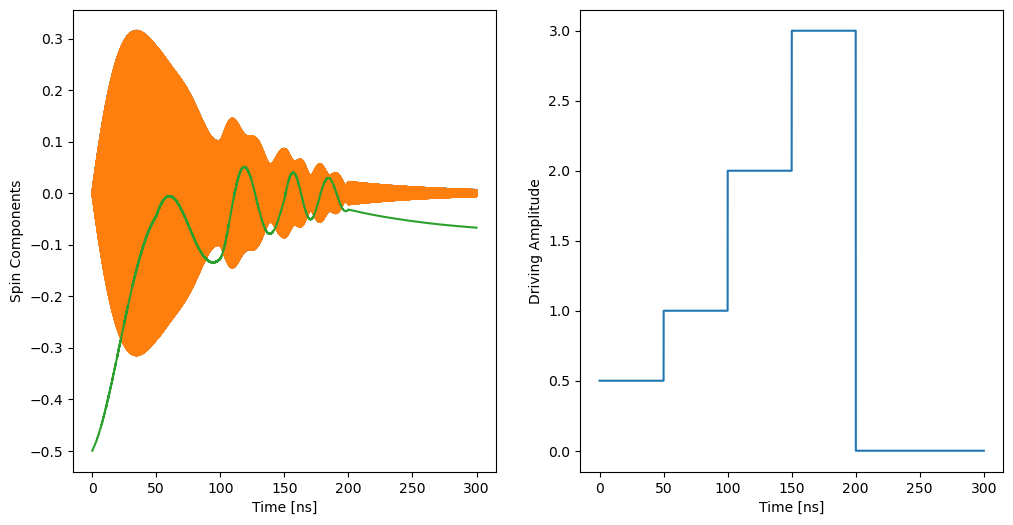

In [15]:
fig, ax = plt.subplots(1,2 , figsize=(12,6))

Sx_pulse = 1/2*np.real(rhot_pulse[:, 0, 1] + rhot_pulse[:, 1, 0])   
Sy_pulse = 1/2*np.real(1j*(rhot_pulse[:, 0,1] - rhot_pulse[:, 1,0]))
Sz_pulse = 1/2*np.real(rhot_pulse[:,1, 1] - rhot_pulse[:,0, 0])


ax[0].plot(time_pulse, Sx_pulse, label=r'$S_x$')  
ax[0].plot(time_pulse, Sy_pulse, label=r'$S_y$')
ax[0].plot(time_pulse, Sz_pulse, label=r'$S_z$')

A_pulse = np.zeros_like(time_pulse)
A_pulse[time_pulse < 50] = A
A_pulse[(time_pulse >= 50) & (time_pulse < 100)] = 2*A
A_pulse[(time_pulse >= 100) & (time_pulse < 150)] = 4*A
A_pulse[(time_pulse >= 150) & (time_pulse < 200)] = 6*A
A_pulse[time_pulse >= 200] = 0

ax[1].plot(time_pulse, A_pulse, label=r'$A(t)$')

ax[0].set_xlabel('Time [ns]')
ax[0].set_ylabel('Spin Components')
ax[1].set_xlabel('Time [ns]')
ax[1].set_ylabel('Driving Amplitude')

plt.show()

#### TODO:
    * Add different time dependence for the current readout.
    * Test for coupled spins.